In [11]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import scipy.io as sio
from dataclasses import dataclass
from typing import List, Tuple
import os
from dotenv import load_dotenv
load_dotenv()
import tidy3d as td
from tidy3d import web
import numpy as np
from pathlib import Path
from stl import mesh
import matplotlib.pyplot as plt
import re

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import sys
import os

# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(fr'H:\phd stuff\tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

In [13]:
tidy3dAPI = os.environ["API_TIDY3D_KEY"]


In [14]:
lambdas = np.array([10,2.5])
sphere,phi,theta=AM.get_sphere(1000)
run = True


Configured successfully.


12:34:41 W. Europe Standard Time WARNING: Structure at 'structures[0]' has      
                                 bounds that extend exactly to simulation edges.
                                 This can cause unexpected behavior. If         
                                 intending to extend the structure to infinity  
                                 along one dimension, use td.inf as a size      
                                 variable instead to make this explicit.        

                                 WARNING: Suppressed 3 WARNING messages.        

12:34:43 W. Europe Standard Time WARNING: Monitor 'field_monitor' estimated     
                                 storage is 12.00GB. Consider making it smaller,
                                 using fewer frequencies, or spatial or temporal
                                 downsampling using 'interval_space' and        
                                 'interval', respectively.                      

12:34:44 W. Europe Standard Time Created task                                   
                                 'LSU_n_2.9275_ff_0.2172_size_0.0734265734265734
                                 2' with task_id                                
                                 'fdve-59314c51-ea2c-4d15-a51f-6155f370a313' and
                                 task_type 'FDTD'.

...

Output()

Output()

12:46:33 W. Europe Standard Time status = postprocess

12:48:14 W. Europe Standard Time status = success

12:48:16 W. Europe Standard Time View simulation result at                      
                                 ]8;id=314122;https://tidy3d.simulation.cloud/workbench?taskId=fdve-59314c51-ea2c-4d15-a51f-6155f370a313\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=389967;https://tidy3d.simulation.cloud/workbench?taskId=fdve-59314c51-ea2c-4d15-a51f-6155f370a313\task]8;;\
                                 ]8;id=389967;https://tidy3d.simulation.cloud/workbench?taskId=fdve-59314c51-ea2c-4d15-a51f-6155f370a313\Id]8;;\]8;id=314122;https://tidy3d.simulation.cloud/workbench?taskId=fdve-59314c51-ea2c-4d15-a51f-6155f370a313\=]8;;\]8;id=851311;https://tidy3d.simulation.cloud/workbench?taskId=fdve-59314c51-ea2c-4d15-a51f-6155f370a313\fdve]8;;\]8;id=314122;https://tidy3d.simulation.cloud/workbench?taskId=fdve-59314c51-ea2c-4d15-a51f-6155f370a313\-59314c51-ea2c-4d15-a51f-6155f370a313']8;;\.

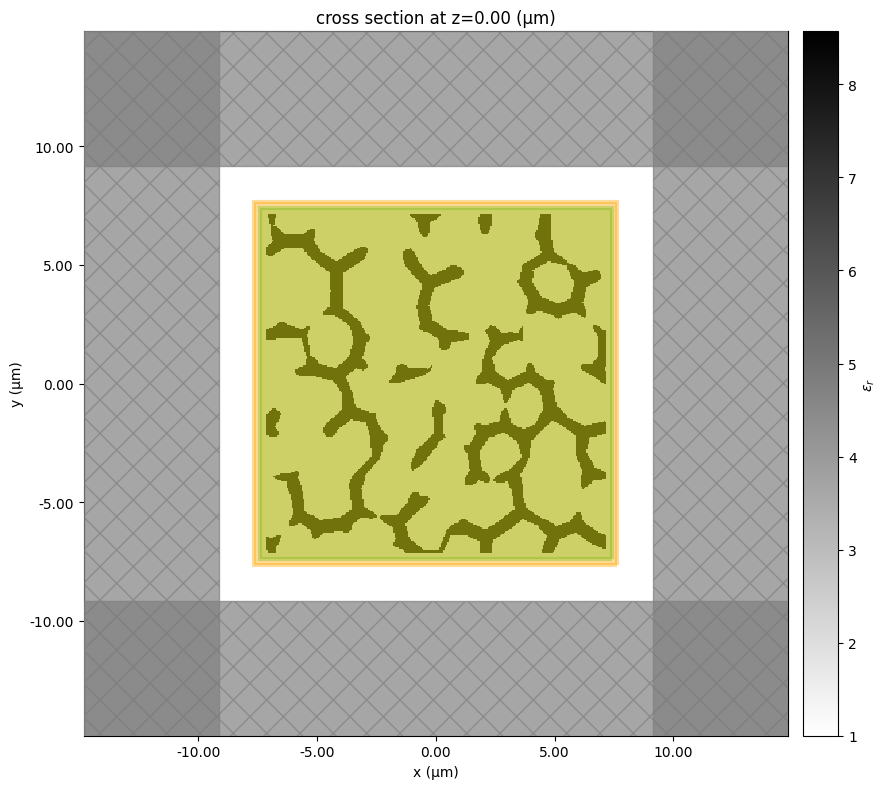

In [15]:
from pdb import run


folder_path = rf"./Structures/Elliptical"
project_name = "20260216_LSU_get_g_factor_elliptical"
postprocess_results = []
runtime_ps = 20e-12
min_steps_per_lambda = 15
cuts=[1.05/14.3]
h5_bg = None
ref = True
for direction in ["z"]: 
    for dirpath, dirnames, filenames in os.walk(folder_path):
        try:
            for filename in filenames:
                if filename.endswith(".h5"):
                    ff = float(re.search(r'ff_([+-]?\d+(?:\.\d+)?)', filename).group(1))
                    n_value = float(re.search(r'n_([+-]?\d+(?:\.\d+)?)', filename).group(1))
                    for cut in cuts:
                        if not (Path(filename).suffix==".h5" or Path(filename).suffix==".stl"):
                            continue 
                        if os.path.isfile(os.path.join(dirpath, filename)):
                            file=os.path.join(dirpath, filename)
                            structure_1 = AM.loadAndRunStructure(key = tidy3dAPI, file_path=file
                                                            ,direction=direction, lambda_range=lambdas,
                                                            box_size=14.3,runtime_ps=runtime_ps,min_steps_per_lambda=min_steps_per_lambda,
                                                           scaling=1,shuoff_condtion=1e-20, verbose=True, 
                                                           monitors=[], flux_monitor_position=18,cell_size_manual=20,#multiplication_factor=2,multiplicate_size=True,
                                                           freqs=250, boundaries="absorbers",
                                                           cut_condition=cut, source="planewave", absorbers=100, use_permittivity=False,sim_name=rf"{Path(filename).stem}_size_{cut}" + (rf"_bg_{h5_bg}" if h5_bg else ""),h5_bg=h5_bg,
                                                           )
                            sim=structure_1.sim
                            monitor_field = td.FieldProjectionAngleMonitor(
                                    center=[0.0, 0.0, 0.0],
                                    
                                    size=(structure_1.t_slab_x+1, structure_1.t_slab_y+1, structure_1.t_slab_z+1),
                                    name="field_monitor",
                                    freqs =structure_1.monitor_freqs,
                                    phi=list(phi),
                                    theta=list(theta),
                                    proj_distance=1e6,  # Set a very large projection distance to approximate far-field conditions
                                    far_field_approx=True, 
                                        )
                            source = td.TFSF(
                                center=(0, 0, 0),
                                size=(structure_1.t_slab_x+0.5, structure_1.t_slab_y+0.5, structure_1.t_slab_z+0.5),
                                source_time=structure_1.gaussian_pulse,
                                injection_axis=2,  # inject along the z axis...
                                direction="+",  # ...in the positive direction, i.e. along z+
                                name="tfsf1",
                                pol_angle=0,
                            )
                            sim=sim.copy(update={"size":(structure_1.t_slab_x+4, structure_1.t_slab_y+4, structure_1.t_slab_z+4),"monitors":[monitor_field],"sources":[source],"grid_spec":td.GridSpec.uniform(structure_1.dl)})
                            folder_desc = rf"H:\phd stuff\tidy3d\data\{project_name}\n_{n_value:.2f}"
                            sim.plot_3d()
                            fig, ax = plt.subplots(1, tight_layout=True, figsize=(16, 8))
                            sim.plot_eps(z=0, freq=structure_1.monitor_freqs[0], ax=ax)
                            if run:
                                os.makedirs(folder_desc, exist_ok=True)
                                sim_name=rf"LSU_{Path(filename).stem}_size_{cut}"
                                if os.path.exists(os.path.join(folder_desc, sim_name+".txt")):
                                    print("Exist!")
                                else:
                                    id =web.upload(sim, folder_name=project_name,task_name=sim_name, verbose=True)
                                    ids = '\n' + id
                                    with open(os.path.join(folder_desc, sim_name+".txt"), "w") as file:
                                        # Write the string to the file
                                        file.write(ids)
                                    web.start(task_id = id)
                                    web.monitor(id)
                            

        except Exception as e:
            print(f"Error processing {dirpath}: {e}")
        
    

